# Where should the bar be?

*Question, Intuition, Math, Code, Assumptions, How it breaks*

Every other chapter in this book defends a method. This one cannot, because
the number at its centre is not a method's output, it is a judgement call:
**the 40th percentile**, on every one of twelve requirements, decides who
even enters the ranking. Move it five points and the qualifying population
changes by hundreds. This chapter shows the curve honestly and refuses to
pick a point on it.

## 1. Question

`cfg.gate_percentile = 40.0` decides who clears the floor on every
requirement before anyone is ranked at all. Why 40? What would 30 or 50 have
done to the answer, and does any value on that dial have a principled claim
to be the "right" one?

## 2. Intuition

Raise the percentile and the gate gets stricter on all twelve requirements at
once, not just one. A player comfortably clear of a lenient floor can still
be pushed under a stricter one on his single weakest requirement, and which
requirement that is differs from player to player. There is no football
argument for 40 over any other number in a reasonable range: it is a
strictness dial, and every position on it is defensible and none is provably
correct. The honest response is not to argue for a number. It is to show what
the dial does and let the reader turn it.

## 3. Math

For requirement $k$ and percentile $p$, the floor is

$$f_k(p) = \text{percentile}\big(\{z_{i,k}\}_{i=1}^{N}, \, p\big)$$

taken over the standardised career profile of all $N$ players. A player
qualifies at $p$ when

$$\forall k: \; z_{i,k} \ge f_k(p)$$

If the twelve requirements were independent, the qualifying share at $p$
would be $(1 - p/100)^{12}$: at $p = 40$, that is $0.6^{12} \approx 0.22\%$,
about 12 of 5,508 players. Chapter 15 measured what the requirements actually
share and the observed rate is nowhere near that, because good players tend
to be good at several things at once. The gate gets stricter as $p$ rises,
but by how much depends on a correlation structure this chapter borrows
rather than re-derives.

## 4. Code

### The curve

In [1]:
from dataclasses import replace

import numpy as np
import pandas as pd

from gambeta import gate, kit, needs

cfg = kit.load()
profile = pd.read_parquet("../data/sample/ranking.parquet")
keys = [r.key for r in needs.OUTFIELD]

curve = pd.DataFrame(
    [
        {
            "percentile": p,
            "qualifiers": int(
                gate.qualify_and_rank(profile, needs.OUTFIELD, replace(cfg, gate_percentile=p))[
                    "qualified"
                ].sum()
            ),
        }
        for p in range(5, 96, 5)
    ]
)

for target in (30, 40, 50):
    n = int(
        gate.qualify_and_rank(profile, needs.OUTFIELD, replace(cfg, gate_percentile=target))[
            "qualified"
        ].sum()
    )
    print(f"percentile {target:>2}: {n:>4} of {len(profile)} qualify")

percentile 30:  588 of 5508 qualify


percentile 40:  265 of 5508 qualify


percentile 50:  121 of 5508 qualify


30 lets in more than double the published default. 50 keeps fewer than half
of it. Neither number is doing anything the gate formula does not do at 40;
they are the same floor, applied at a different height.

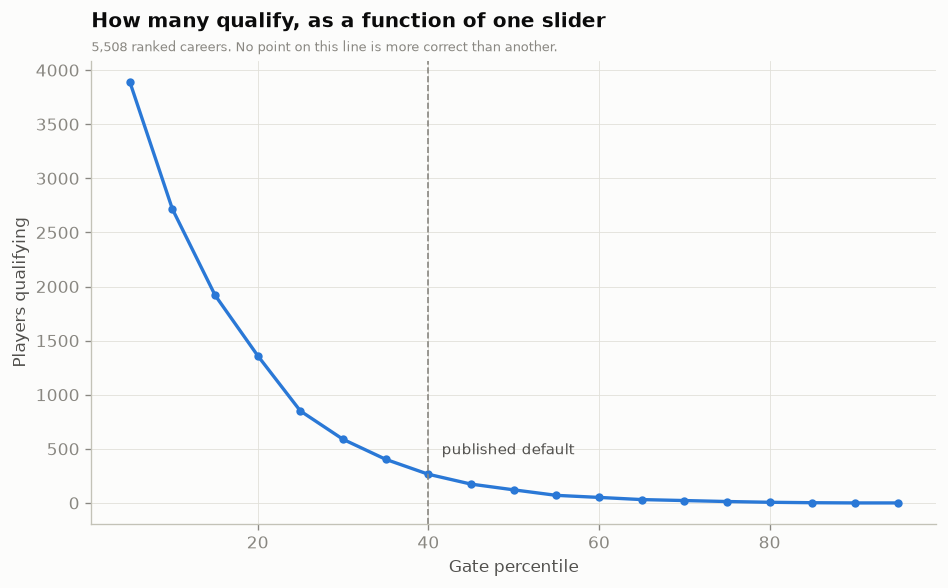

In [2]:
import matplotlib.pyplot as plt

from gambeta import tifo

tifo.apply_theme(dark=False)
c = tifo.palette(dark=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    curve["percentile"],
    curve["qualifiers"],
    color=c["accent"],
    linewidth=2,
    marker="o",
    markersize=4,
)
ax.axvline(40, color=c["muted"], linestyle="--", linewidth=1)
ax.annotate(
    "published default",
    xy=(40, curve.loc[curve["percentile"] == 40, "qualifiers"].item()),
    xytext=(8, 12),
    textcoords="offset points",
    fontsize=9,
    color=c["secondary"],
)
ax.set_xlabel("Gate percentile")
ax.set_ylabel("Players qualifying")
ax.set_title(
    "How many qualify, as a function of one slider",
    loc="left",
    fontsize=12,
    fontweight="bold",
    color=c["primary"],
    pad=20,
)
ax.text(
    0,
    1.02,
    "5,508 ranked careers. No point on this line is more correct than another.",
    transform=ax.transAxes,
    fontsize=8,
    color=c["muted"],
)
fig.tight_layout()

### Where the top ten drop out

"Who is best" and "who qualifies at all" are different questions, and the
percentile slider only touches the second one directly: weights (the
`ARGUMENTS` vectors) reorder qualifiers and can never requalify anybody the
percentile has already excluded. But a player who fails to qualify is not
ranked at all, so pushing the floor high enough removes even Messi. Each of
the current top ten has its own breaking point, found by raising the
percentile until it fails.

In [3]:
ranked40 = gate.qualify_and_rank(profile, needs.OUTFIELD, cfg)
top10 = ranked40[ranked40["qualified"]].nlargest(10, "score")


def last_qualifying_percentile(player_id: str) -> int | None:
    last_ok = None
    for p in range(0, 100):
        ranked_p = gate.qualify_and_rank(profile, needs.OUTFIELD, replace(cfg, gate_percentile=p))
        if not ranked_p.loc[ranked_p["player_id"] == player_id, "qualified"].item():
            break
        last_ok = p
    return last_ok


dropouts = pd.DataFrame(
    {
        "player": top10["player"].to_numpy(),
        "qualifies through": [last_qualifying_percentile(pid) for pid in top10["player_id"]],
    }
).sort_values("qualifies through")
dropouts

,player,qualifies through
7,Erling Haaland,44
4,Robert Lewandowski,44
9,Ruud van Nistelrooy,63
8,Luis Suárez,67
2,Kylian Mbappé,69
6,Karim Benzema,70
1,Cristiano Ronaldo,75
5,Harry Kane,77
3,Thierry Henry,78
0,Lionel Messi,87


Erling Haaland and Robert Lewandowski are first out, each qualifying only
through the 44th percentile, four points past the published default. Lionel
Messi survives to 87, further than anyone else in the top ten: not because he
is the best player in this ranking, that is a separate claim, but because he
is the one whose weakest requirement is furthest from its own floor.

### The elimination grid: which single requirement gets to each one first

The dropout percentile above is a minimum over twelve numbers, one per
requirement: whichever requirement a player is weakest on, relative to the
population, is the one that eliminates him first as the floor rises. Which
requirement that is differs from player to player, and the grid below makes
that visible in one image instead of ten separate stories.

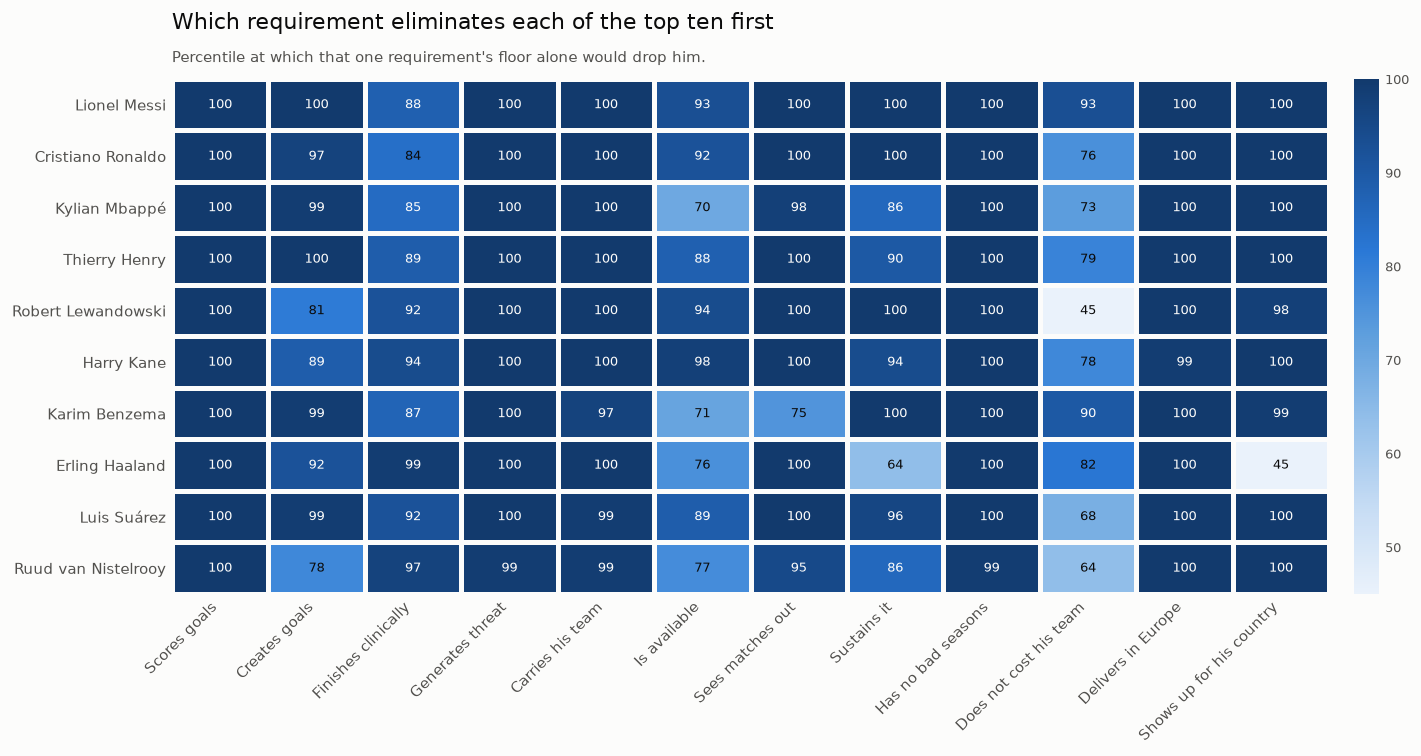

In [4]:
labels = {r.key: r.label for r in needs.OUTFIELD}


def elimination_percentile(value: float, column: str) -> int:
    values = profile[column].to_numpy(dtype=float)
    for p in range(0, 101):
        if value < np.percentile(values, p):
            return p
    return 100


grid = pd.DataFrame(
    {labels[k]: [elimination_percentile(row[k], k) for _, row in top10.iterrows()] for k in keys},
    index=top10["player"],
)

fig = tifo.matrix(
    grid,
    title="Which requirement eliminates each of the top ten first",
    subtitle="Percentile at which that one requirement's floor alone would drop him.",
    fmt="{:.0f}",
)

Read a row's minimum against the dropout table above: it is the same
number, because the dropout percentile *is* the minimum across that row.
"Does not cost his team" is the tightest column for six of the top ten, with
"is available" and now "shows up for his country" taking the others, which
is a hint about where this particular gate is under the most pressure, not a
verdict on any one of them.

## 5. Assumptions

1. **The percentile is computed on the full ranked population, not just
   qualifiers.** Moving it does not change who is *measured*, only who
   clears the bar; 5,508 careers stay in the denominator throughout.
2. **Every requirement's floor moves independently.** The gate does not
   trade a weak requirement off against a strong one; failing by a hair on
   one axis eliminates exactly as completely as failing by a mile.
3. **Weights are a separate mechanism and do not appear here.** The
   `ARGUMENTS` vectors reorder qualifiers; they cannot requalify anyone the
   percentile has already excluded. This chapter is only about the floor.

## 6. How it breaks

This chapter is not going to end with a recommended percentile, and that is
the point rather than an evasion. Every value in the curve above is a
legitimate reading of "must have": 30 is generous and lets in 588 players,
including plenty who are good at three or four things and unremarkable at
everything else; 50 is severe and keeps 121, few enough that the gate alone
is doing most of the work the ranking is supposed to do. Neither is wrong.

**The place this actually gets decided is not a chapter, it is the
dashboard's percentile slider.** A reader who wants a stricter or looser
definition of "must have" moves it and watches the qualifying population
change in front of them, which is a more honest answer than a paragraph
declaring 40 correct would be.

In [5]:
for p in (1, 5, 10, 20, 30, 40, 50):
    values = profile["continental"].to_numpy(dtype=float)
    floor = np.percentile(values, p)
    print(f"p={p:>2}: continental alone eliminates {(values < floor).sum():>4} of {len(profile)}")

tied = (profile["continental"] == profile["continental"].min()).mean()
print(f"\nshare of the population tied at the minimum continental value: {tied:.4%}")

p= 1: continental alone eliminates   56 of 5508
p= 5: continental alone eliminates  276 of 5508
p=10: continental alone eliminates  551 of 5508
p=20: continental alone eliminates 1102 of 5508
p=30: continental alone eliminates 1653 of 5508
p=40: continental alone eliminates 2203 of 5508
p=50: continental alone eliminates 2754 of 5508

share of the population tied at the minimum continental value: 0.0182%


One design risk was named before the numbers existed and is worth checking
against them now that they do: most careers in the ranked population never
play a Champions League minute, so before standardisation most of
`continental` is a tie at exactly zero. If z-scoring preserved that tie, a
low floor could eliminate either all of the tied careers at once or none of
them, and the curve would jump in one population-sized step instead of
climbing smoothly. It does not, and the check matters more now than it did:
since 2026-08-16 the column is z-scored within each `(season)` pooled across
leagues, so every zero-value player in one season really does share one
z-value. What breaks the tie is the career average across seasons of
different length, taken with minutes weights, which scatters the shared
within-season values before the gate ever sees them. Only a fraction of a
percent of the population sits at the true post-standardisation minimum, and
the elimination count above climbs by ones and hundreds, at every percentile
checked, not by five figures at one of them. Neither the formula nor
`gate_percentile` changes in response to this, it is a check that the risk
did not materialise, not a fix for one that did.